# Feature Engineering and Modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.subset import subset
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, roc_auc_score,
                             confusion_matrix)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve
import warnings

warnings.filterwarnings('ignore', category=UserWarning, message='.*unknown categories.*')

In [2]:
df = pd.read_csv('../data/processed_data/processed_data.csv')

In [3]:
hg_threshold = 0.2
df = df.dropna(subset=['hg']).copy()
df['safety_status'] = np.where(df['hg'] < hg_threshold, 'safe', 'unsafe')

In [4]:
X = df[['f_length', 't_length', 'weight', 'age', 'w_name','w_type', 'common_name', 'sex', 'maturity', 'year']]
y = df['safety_status']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [6]:
# Define features
categorical_features = ['w_name', 'w_type', 'common_name', 'sex', 'maturity', 'year']
numerical_features = ['f_length', 't_length', 'weight', 'age']

In [7]:
numeric_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_steps, numerical_features),
    ('cat', categorical_steps, categorical_features)
])

In [8]:
models = {
    'logistic_regression': Pipeline([
        ('prep', preprocessor),
        ('classifier', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'hist_gradient_boosting': Pipeline([
        ('prep', preprocessor),
        ('classifier', HistGradientBoostingClassifier(random_state=42))
    ]),
    'random_forest': Pipeline([
        ('prep', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    'gradient_boosting': Pipeline([
        ('prep', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]),
    'decision_tree': Pipeline([
        ('prep', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
}

In [9]:
# Defining the dictionary to store the results of each model
results = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Iterating over each model in the dictionary
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='roc_auc')
    results[name] = {
        'mean_auc': cv_scores.mean(),
        'std_auc': cv_scores.std()
    }
    print(f"{name}: AUC = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Select best model based on mean AUC
best_model_name = max(results, key=lambda x: results[x]['mean_auc'])
print(f"\nBest model: {best_model_name}")

logistic_regression: AUC = 0.952 (+/- 0.005)
hist_gradient_boosting: AUC = 0.953 (+/- 0.005)
random_forest: AUC = 0.951 (+/- 0.004)
gradient_boosting: AUC = 0.925 (+/- 0.004)
decision_tree: AUC = 0.863 (+/- 0.009)

Best model: hist_gradient_boosting


In [10]:
if best_model_name == 'logistic_regression':
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    }
elif best_model_name == 'hist_gradient_boosting':
    param_grid = {
        'classifier__max_iter': [100, 200, 300],
        'classifier__learning_rate': [0.05, 0.1, 0.2],
        'classifier__max_depth': [4, 6, 8],
        'classifier__min_samples_leaf': [20, 50, 100],
        'classifier__l2_regularization': [0, 0.1, 1]
    }
elif best_model_name == 'random_forest':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],      # Number of trees
        'classifier__max_depth': [5, 10, 15]       # Tree depth (None = unlimited)
    }
elif best_model_name == 'gradient_boosting':
    param_grid = {
        'classifier__learning_rate': [0.05, 0.1],    # Step size for each tree
        'classifier__n_estimators': [100, 200]       # Number of boosting rounds
    }

# Grid search tests all parameter combinations
grid_search = GridSearchCV(
    models[best_model_name],
    param_grid,
    cv=cv,                    # 5-fold cross-validation for each combination
    scoring='roc_auc',
    n_jobs=-1,                # Use all CPU cores (faster),
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__l2_regularization': [0, 0.1, ...], 'classifier__learning_rate': [0.05, 0.1, ...], 'classifier__max_depth': [4, 6, ...], 'classifier__max_iter': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scori

In [11]:
# Displaying the best parameters found by the grid search
print(f"Best parameters: {grid_search.best_params_}", "\n")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

Best parameters: {'classifier__l2_regularization': 1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__max_iter': 300, 'classifier__min_samples_leaf': 20} 

Best cross-validation score: 0.954


In [12]:
best_model = grid_search.best_estimator_

# Make predictions on held-out test set (never seen during training)
y_pred = best_model.predict(X_test)           # Class predictions ('safe' or 'unsafe')
y_proba = best_model.predict_proba(X_test)[:, 1]  # Probability of 'unsafe' class

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

        safe       0.90      0.84      0.87       723
      unsafe       0.87      0.93      0.90       869

    accuracy                           0.89      1592
   macro avg       0.89      0.88      0.89      1592
weighted avg       0.89      0.89      0.89      1592



In [13]:
# Printing the confusion matrix
print(confusion_matrix(y_test, y_pred), "\n")

# Calculating the false positive and false negative rates
true_positives = confusion_matrix(y_test, y_pred)[1, 1]
false_positives = confusion_matrix(y_test, y_pred)[0, 1]
true_negatives = confusion_matrix(y_test, y_pred)[0, 0]
false_negatives = confusion_matrix(y_test, y_pred)[1, 0]

print("True positives:", true_positives)
print("False positives:", false_positives)
print("True negatives:", true_negatives)
print("False negatives:", false_negatives)

[[608 115]
 [ 65 804]] 

True positives: 804
False positives: 115
True negatives: 608
False negatives: 65


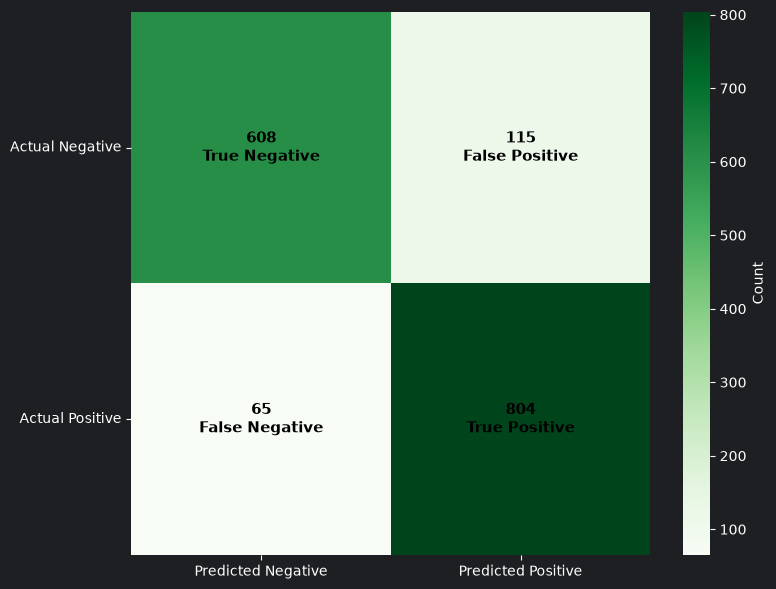

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=False, fmt='d', cmap='Greens', ax=ax, cbar_kws={"label": "Count"})

labels = {
    (0, 0): ("TN", "True Negative"),
    (0, 1): ("FP", "False Positive"),
    (1, 0): ("FN", "False Negative"),
    (1, 1): ("TP", "True Positive"),
}

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        acronym, full_label = labels[(i, j)]

        # Stack: count → acronym → full label (3 lines)
        text = f"{count}\n{full_label}"

        ax.text(j + 0.5, i + 0.5, text,
                ha="center", va="center", fontsize=11, fontweight="bold", color="black")

ax.set_xticks(np.arange(cm.shape[1]) + 0.5)
ax.set_yticks(np.arange(cm.shape[0]) + 0.5)
ax.set_xticklabels(["Predicted Negative", "Predicted Positive"])
ax.set_yticklabels(["Actual Negative", "Actual Positive"], rotation=0)
plt.tight_layout()
plt.show()

In [15]:
best = grid_search.best_estimator_
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='unsafe')
recall = recall_score(y_test, y_pred, pos_label='unsafe')
f1 = f1_score(y_test, y_pred, pos_label='unsafe')

In [16]:
cat_no_name = [c for c in categorical_features if c != 'w_name']
prep_no_name = ColumnTransformer([
    ('num', numeric_steps, numerical_features),
    ('cat', categorical_steps, cat_no_name),
])
model_no_name = Pipeline([
    ('prep', prep_no_name),
    ('classifier', HistGradientBoostingClassifier(
        random_state=42, l2_regularization=1.0, learning_rate=0.1,
        max_depth=8, max_iter=300, min_samples_leaf=20))
])

s = cross_val_score(model_no_name, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"without w_name: {s.mean():.3f} +/- {s.std():.3f}")

without w_name: 0.912 +/- 0.010


In [17]:
groups = df.loc[X_train.index, 'w_name']
gcv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
s = cross_val_score(model_no_name, X_train, y_train, groups=groups,
                    cv=gcv, scoring='roc_auc', n_jobs=-1)
print(f"unseen waterbodies: {s.mean():.3f} +/- {s.std():.3f}")

unseen waterbodies: 0.817 +/- 0.045


In [18]:
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

        safe      0.903     0.841     0.871       723
      unsafe      0.875     0.925     0.899       869

    accuracy                          0.887      1592
   macro avg      0.889     0.883     0.885      1592
weighted avg      0.888     0.887     0.886      1592



# Minimal Model

In [19]:
X_mini = df[['w_name', 'weight', 't_length']]
y_mini = df['safety_status']

In [20]:
X_train_mini, X_test_mini, y_train_mini, y_test_mini = train_test_split(X_mini, y_mini, test_size=0.25, stratify=y_mini, random_state=42)

In [21]:
# Define features
cat_feat_mini = ['w_name']
num_feat_mini= ['t_length', 'weight']

In [22]:
num_steps_mini = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_steps_mini = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_mini = ColumnTransformer([
    ('num', num_steps_mini, num_feat_mini),
    ('cat', cat_steps_mini, cat_feat_mini)
])

In [23]:
models_mini = {
    'logistic_regression': Pipeline([
        ('prep', preprocessor_mini),
        ('classifier', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'hist_gradient_boosting': Pipeline([
        ('prep', preprocessor_mini),
        ('classifier', HistGradientBoostingClassifier(random_state=42))
    ]),
    'random_forest': Pipeline([
        ('prep', preprocessor_mini),
        ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    'gradient_boosting': Pipeline([
        ('prep', preprocessor_mini),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]),
    'decision_tree': Pipeline([
        ('prep', preprocessor_mini),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
}

In [24]:
# Defining the dictionary to store the results of each model
results_mini = {}

cv_mini = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Iterating over each model in the dictionary
for name_mini, model_mini in models_mini.items():
    cv_scores_mini = cross_val_score(model_mini, X_train_mini, y_train_mini,
                                cv=cv_mini, scoring='roc_auc')
    results_mini[name_mini] = {
        'mean_auc': cv_scores_mini.mean(),
        'std_auc': cv_scores_mini.std()
    }
    print(f"{name_mini}: AUC = {cv_scores_mini.mean():.3f} (+/- {cv_scores_mini.std():.3f})")

# Select best model based on mean AUC
best_model_name_mini = max(results_mini, key=lambda x: results_mini[x]['mean_auc'])
print(f"\nBest model: {best_model_name_mini}")

logistic_regression: AUC = 0.864 (+/- 0.013)
hist_gradient_boosting: AUC = 0.883 (+/- 0.007)
random_forest: AUC = 0.902 (+/- 0.009)
gradient_boosting: AUC = 0.851 (+/- 0.014)
decision_tree: AUC = 0.791 (+/- 0.013)

Best model: random_forest


In [25]:
if best_model_name_mini == 'logistic_regression':
    param_grid_mini = {
        'classifier__C': [0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    }
elif best_model_name_mini == 'hist_gradient_boosting':
    param_grid_mini = {
        'classifier__max_iter': [100, 200, 300],
        'classifier__learning_rate': [0.05, 0.1, 0.2],
        'classifier__max_depth': [4, 6, 8],
        'classifier__min_samples_leaf': [20, 50, 100],
        'classifier__l2_regularization': [0, 0.1, 1]
    }
elif best_model_name_mini == 'random_forest':
    param_grid_mini = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [5, 10, 15],
        'classifier__min_samples_leaf': [1, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', None],
        'classifier__bootstrap': [True, False]
    }
elif best_model_name_mini == 'gradient_boosting':
    param_grid_mini = {
        'classifier__learning_rate': [0.05, 0.1],    # Step size for each tree
        'classifier__n_estimators': [100, 200]       # Number of boosting rounds
    }

# Grid search tests all parameter combinations
grid_search_mini = GridSearchCV(
    models_mini[best_model_name_mini],
    param_grid_mini,
    cv=cv_mini,                    # 5-fold cross-validation for each combination
    scoring='roc_auc',
    n_jobs=-1,                # Use all CPU cores (faster),
    verbose=1
)

# Fit the grid search
grid_search_mini.fit(X_train_mini, y_train_mini)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [True, False], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scor

In [26]:
# Get the best model from grid search
best_model_name_mini = grid_search_mini.best_estimator_

# Make predictions on held-out test set (never seen during training)
y_pred_mini = best_model_name_mini.predict(X_test_mini)           # Class predictions ('safe' or 'unsafe')
y_proba_mini = best_model_name_mini.predict_proba(X_test_mini)[:, 1]  # Probability of 'unsafe' class

accuracy_mini = accuracy_score(y_test_mini, y_pred_mini)
precision_mini = precision_score(y_test_mini, y_pred_mini, pos_label='unsafe')
recall_mini = recall_score(y_test_mini, y_pred_mini, pos_label='unsafe')
f1_mini = f1_score(y_test_mini, y_pred_mini, pos_label='unsafe')

print("Classification Report:")
print(classification_report(y_test_mini, y_pred_mini))

Classification Report:
              precision    recall  f1-score   support

        safe       0.91      0.50      0.65       723
      unsafe       0.70      0.96      0.81       869

    accuracy                           0.75      1592
   macro avg       0.80      0.73      0.73      1592
weighted avg       0.80      0.75      0.74      1592



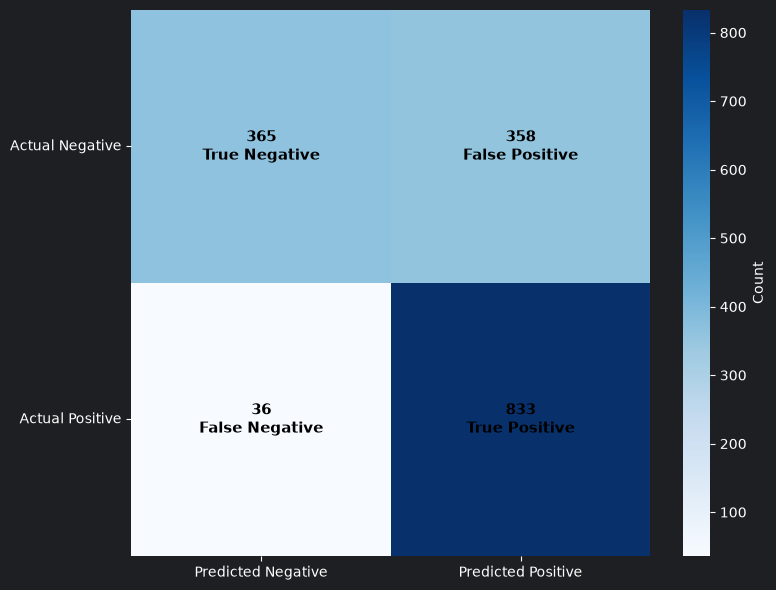

In [27]:
cm_mini = confusion_matrix(y_test_mini, y_pred_mini)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_mini, annot=False, fmt='d', cmap='Blues', ax=ax, cbar_kws={"label": "Count"})

labels = {
    (0, 0): ("TN", "True Negative"),
    (0, 1): ("FP", "False Positive"),
    (1, 0): ("FN", "False Negative"),
    (1, 1): ("TP", "True Positive"),
}

for i in range(cm_mini.shape[0]):
    for j in range(cm_mini.shape[1]):
        count = cm_mini[i, j]
        acronym, full_label = labels[(i, j)]

        # Stack: count → acronym → full label (3 lines)
        text = f"{count}\n{full_label}"

        ax.text(j + 0.5, i + 0.5, text,
                ha="center", va="center", fontsize=11, fontweight="bold", color="black")

ax.set_xticks(np.arange(cm_mini.shape[1]) + 0.5)
ax.set_yticks(np.arange(cm_mini.shape[0]) + 0.5)
ax.set_xticklabels(["Predicted Negative", "Predicted Positive"])
ax.set_yticklabels(["Actual Negative", "Actual Positive"], rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Creating the confusion matrix
confusion_matrix(y_test_mini, y_pred_mini)

# Calculating the false positive and false negative rates
true_positives_mini = confusion_matrix(y_test_mini, y_pred_mini)[1, 1]
false_positives_mini = confusion_matrix(y_test_mini, y_pred_mini)[0, 1]
true_negatives_mini = confusion_matrix(y_test_mini, y_pred_mini)[0, 0]
false_negatives_mini = confusion_matrix(y_test_mini, y_pred_mini)[1, 0]

print("True positives:", true_positives_mini)
print("False positives:", false_positives_mini)
print("True negatives:", true_negatives_mini)
print("False negatives:", false_negatives_mini)

True positives: 833
False positives: 358
True negatives: 365
False negatives: 36


# Comparison

In [29]:
full_model_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

mini_model_metrics = {
    'Accuracy': accuracy_mini,
    'Precision': precision_mini,
    'Recall': recall_mini,
    'F1 Score': f1_mini
}

# Create a DataFrame
df_model_metrics = pd.DataFrame([full_model_metrics, mini_model_metrics], index=['Full Model', 'Mini Model'])
print(df_model_metrics)

       coll_date             w_name     w_type     common_name     sex  \
0     2021-09-28  40 Mile Reservoir  Reservoir  Lake Whitefish  Female   
1     2021-09-28  40 Mile Reservoir  Reservoir  Lake Whitefish  Female   
2     2021-09-28  40 Mile Reservoir  Reservoir  Lake Whitefish    Male   
3     2021-09-28  40 Mile Reservoir  Reservoir  Lake Whitefish  Female   
4     2021-09-28  40 Mile Reservoir  Reservoir  Lake Whitefish  Female   
...          ...                ...        ...             ...     ...   
6368  2018-09-25          Wolf Lake       Lake         Walleye    Male   
6369  2018-09-26          Wolf Lake       Lake         Walleye    Male   
6370  2018-09-26          Wolf Lake       Lake         Walleye    Male   
6371  2018-09-26          Wolf Lake       Lake         Walleye  Female   
6372  2018-09-26          Wolf Lake       Lake         Walleye    Male   

      f_length  t_length  weight  maturity   age     hg  year safety_status  
0        383.0     439.0   0.610 